# Задание 1. Предсказание оттока клиентов телеком-оператора
  
**Датасет:** Telco Customer Churn (IBM), [ссылка на данные](https://github.com/IBM/telco-customer-churn-on-icp4d) / [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**Содержание**
1. Постановка задачи (бизнес и ML)
2. Выбор метрики
3. Разведочный анализ данных (EDA)
4. Общие выводы

## 1. Постановка задачи

### 1.1 Бизнес-постановка
Телеком-оператор теряет клиентов, а привлечение нового клиента стоит заметно дороже, чем удержание существующего.
Цель — заранее выявлять клиентов, которые с высокой вероятностью уйдут в ближайший период, чтобы отдел маркетинга мог
предложить им удерживающее предложение (скидку, персональный тариф, апгрейд услуг) и сократить отток.

### 1.2 ML-постановка
**Бинарная классификация.** По признакам клиента (срок обслуживания, тип контракта, подключённые услуги, способ оплаты,
ежемесячный платёж и т.д.) предсказать целевую переменную `Churn` (Процент клиентов/подписчиков, которые перестают пользоваться продуктом или услугой компании в течение определенного периода времени):
- `1` (Yes) — клиент ушёл,
- `0` (No) — клиент остался.

На выходе модель должна давать **вероятность оттока**, по которой клиенты ранжируются, а порог отсечения выбирается исходя из бюджета кампании удержания.

### 1.3 Данные
Telco Customer Churn — около 7 000 клиентов, 20 признаков и целевая переменная. Признаки покрывают:
 **демографию:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`;
 **услуги:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`;
 **контракт и оплату:** `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`, `tenure`.

Объёма и разнообразия признаков достаточно для построения и оценки модели, а реальный дисбаланс классов делает задачу близкой к реальной

## 2. Выбор метрики

**Основная метрика: PR-AUC (Average Precision).** Вспомогательные: **Recall при фиксированной Precision** и **F1** на выбранном пороге

**Обоснование:** Классы несбалансированы (~26% оттока), поэтому accuracy завышает качество (модель «все остались» даст ~73%),
а PR-AUC оценивает качество поиска именно положительного класса. Для бизнеса важен баланс: найти как можно больше уходящих клиентов (Recall),
но не тратить бюджет удержания на лояльных (Precision), поэтому итоговый порог подбирается по F1 или по заданной стоимости ошибок.

## 3. Разведочный анализ данных (EDA)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

### 3.1 Загрузка данных и базовые характеристики

In [ ]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


В датасете 7043 строки и 21 столбец. Числовых признаков мало (`tenure`, `MonthlyCharges`, `SeniorCitizen` как бинарный флаг),
подавляющее большинство признаков категориальные. Обращаем внимание, что: `TotalCharges` имеет тип `object`, хотя по смыслу это число —
значит, в столбце есть нечисловые значения, и его надо привести к числовому типу

### 3.2 Пропуски, типы и дубликаты

In [ ]:
# TotalCharges прочитан как строка: ищем проблемные значения
bad = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]
print("Нечисловых значений в TotalCharges:", len(bad))
display(bad[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("\nПропуски по столбцам:")
print(df.isna().sum()[lambda s: s > 0])
print("\nДубликатов (без customerID):", df.drop(columns="customerID").duplicated().sum())
print("Уникальных customerID:", df["customerID"].nunique(), "из", len(df))

Нечисловых значений в TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No



Пропуски по столбцам:
TotalCharges    11
dtype: int64

Дубликатов (без customerID): 22
Уникальных customerID: 7043 из 7043


Все проблемные значения `TotalCharges` — это пробелы у клиентов с `tenure = 0`, то есть у новых клиентов, которые ещё ничего не оплатили.
Это не случайные пропуски, поэтому логично **заполнить их нулём**, а не средним или медианой. Идентификатор `customerID` уникален и не несёт информации о поведении —
его нужно удалить перед обучением, иначе модель может переобучиться на шуме. Полных дубликатов практически нет (небольшое число совпадений по признакам —
это разные клиенты с одинаковыми характеристиками, а не ошибка).

In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["Churn_bin"] = (df["Churn"] == "Yes").astype(int)

### 3.3 Целевая переменная

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


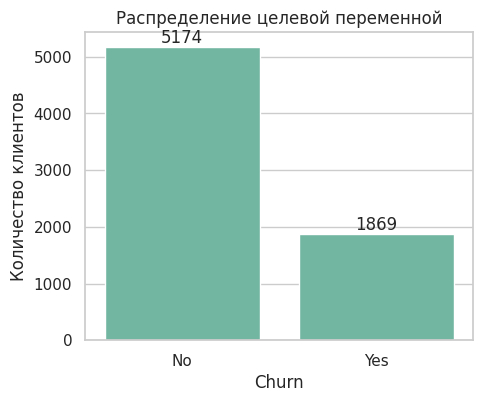

In [ ]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", ax=ax)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Распределение целевой переменной")
ax.set_xlabel("Churn")
ax.set_ylabel("Количество клиентов")
plt.show()

Классы несбалансированы: примерно 73% клиентов остались и 27% ушли. Дисбаланс умеренный, но он уже делает accuracy неинформативной метрикой
(тривиальный классификатор даёт ~73%). При разбиении на train/test нужна **стратификация** по `Churn`, а при обучении — стоит рассмотреть `class_weight="balanced"`
или подбор порога классификации. Это подтверждает выбор PR-AUC в качестве основной метрики

### 3.4 Числовые признаки

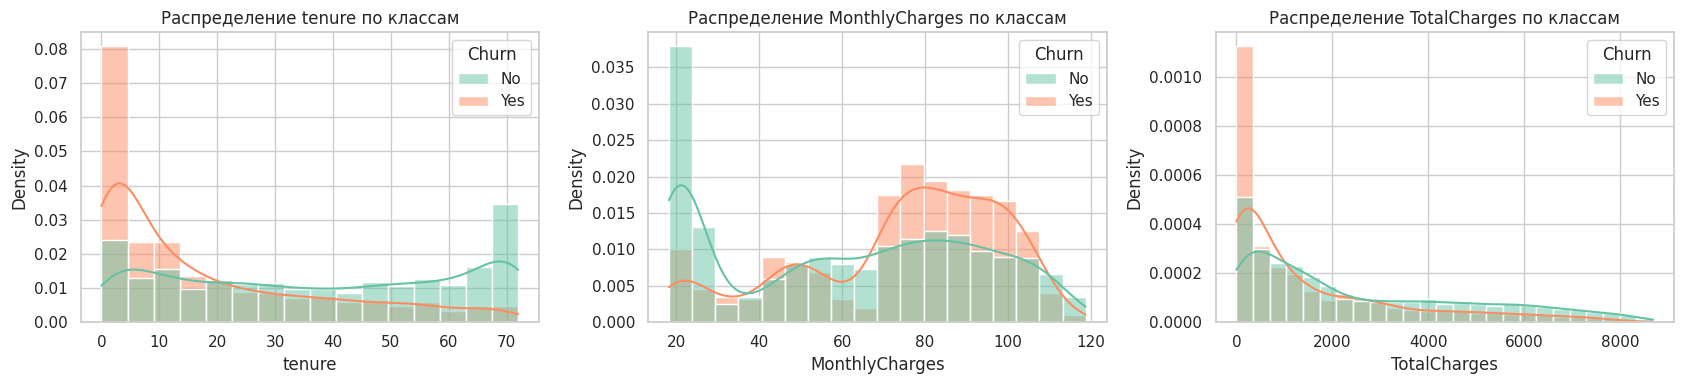

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(f"Распределение {col} по классам")
plt.tight_layout()
plt.show()

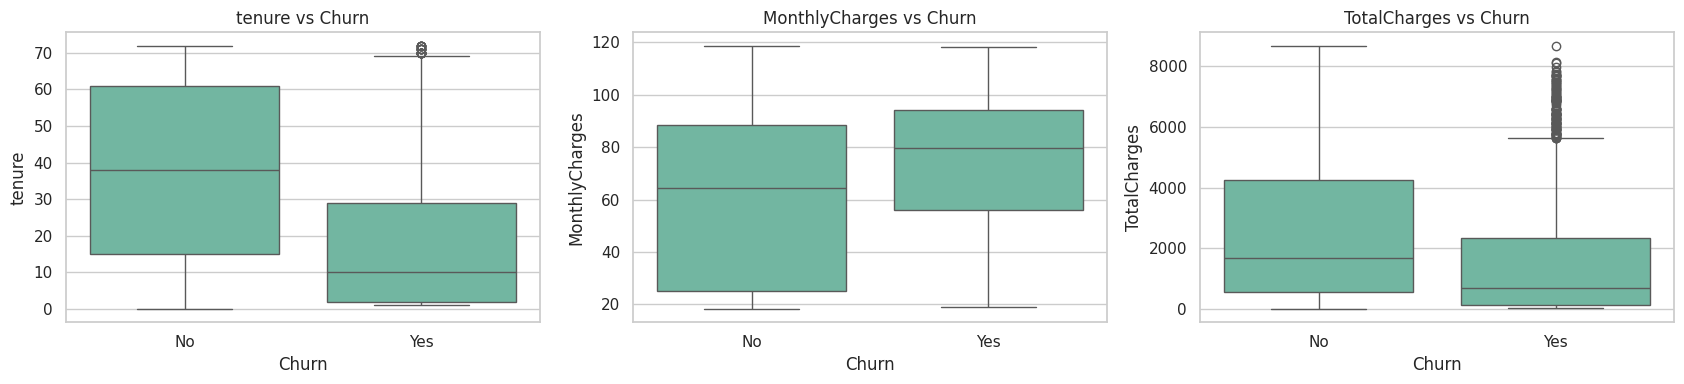

tenure        MonthlyCharges        TotalCharges        
        mean median           mean median         mean  median
Churn                                                         
No      37.6   38.0           61.3   64.4       2549.9  1679.5
Yes     18.0   10.0           74.4   79.6       1531.8   703.6

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

df.groupby("Churn")[num_cols].agg(["mean", "median"]).round(1)


**`tenure`:** у ушедших клиентов распределение сильно смещено к малым значениям — отток концентрируется в **первых месяцах** обслуживания,
у оставшихся распределение более равномерное с пиком на длительных сроках. Признак очень информативен.

**`MonthlyCharges`:** ушедшие клиенты в среднем платят **больше** (дорогие тарифы с интернетом по оптоволокну). Распределение бимодальное:
отдельный пик на низких значениях соответствует клиентам только с телефонной связью.

**`TotalCharges`:** сильно скошен вправо, поскольку это накопленная сумма и она растёт со сроком обслуживания.
Для линейных моделей стоит рассмотреть логарифмирование или масштабирование.

**Выбросы:** выраженных аномальных выбросов на boxplot нет, удалять наблюдения не требуется.

### 3.5 Категориальные признаки и отток

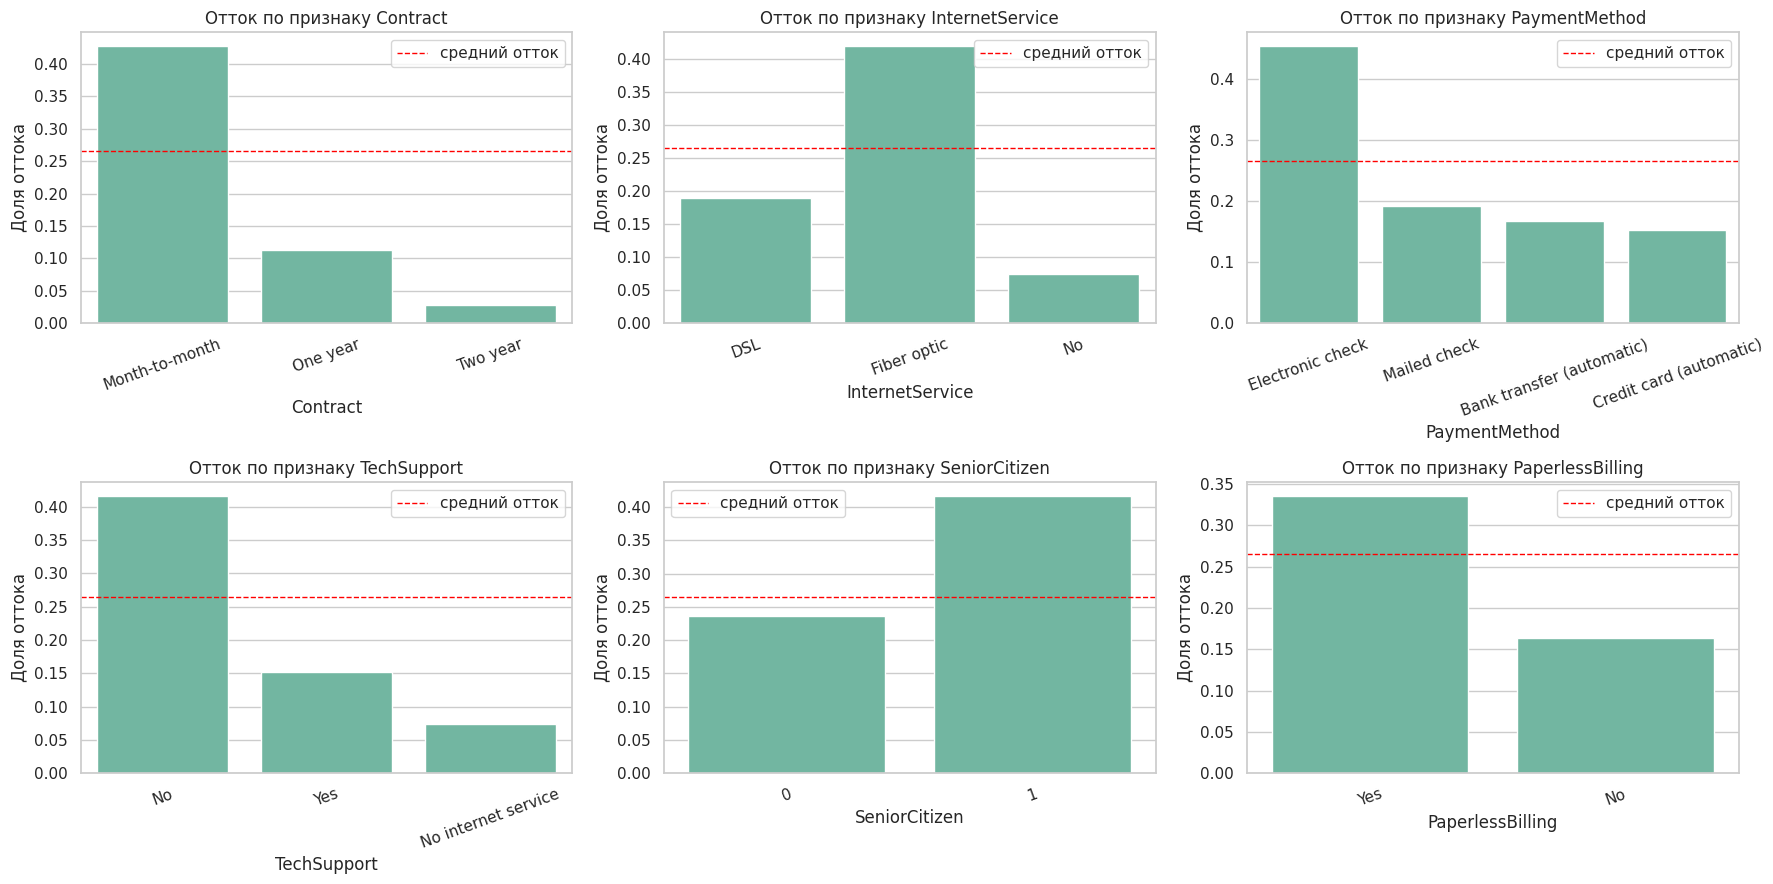

In [ ]:
cat_cols = ["Contract", "InternetService", "PaymentMethod",
            "TechSupport", "SeniorCitizen", "PaperlessBilling"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.barplot(data=df, x=col, y="Churn_bin", errorbar=None, ax=ax)
    ax.axhline(df["Churn_bin"].mean(), color="red", ls="--", lw=1, label="средний отток")
    ax.set_ylabel("Доля оттока")
    ax.set_title(f"Отток по признаку {col}")
    ax.tick_params(axis="x", rotation=20)
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport"]:
    print((df.groupby(col)["Churn_bin"].agg(["mean", "count"])
             .rename(columns={"mean": "churn_rate"}).round(3)), "\n")

                churn_rate  count
Contract                         
Month-to-month       0.427   3875
One year             0.113   1473
Two year             0.028   1695 

                 churn_rate  count
InternetService                   
DSL                   0.190   2421
Fiber optic           0.419   3096
No                    0.074   1526 

                           churn_rate  count
PaymentMethod                               
Bank transfer (automatic)       0.167   1544
Credit card (automatic)         0.152   1522
Electronic check                0.453   2365
Mailed check                    0.191   1612 

                     churn_rate  count
TechSupport                           
No                        0.416   3473
No internet service       0.074   1526
Yes                       0.152   2044 




**`Contract`:** при помесячном контракте отток около 43%, при годовом ~11%, при двухлетнем ~3%. Это один из самых сильных предикторов.

Бизнес-вывод: клиентов с помесячной оплатой нужно мотивировать переходить на долгосрочные контракты.

**`InternetService`:** у пользователей оптоволокна (Fiber optic) отток около 42%, у DSL ~19%, у клиентов без интернета ~7%.
Возможные причины — цена и качество услуги.

**`PaymentMethod`:** при оплате электронным чеком отток около 45%, заметно выше, чем при автоплатежах (~15–17%).
Автоматические способы оплаты связаны с большей лояльностью.

**`TechSupport`:** клиенты без техподдержки уходят значительно чаще.

**`SeniorCitizen`:** пожилые клиенты уходят чаще (около 42% против 24%), но их мало (~16% выборки).

**Подготовка данных:** категориальных признаков много, потребуется one-hot encoding (для деревьев — также допустим ordinal/target encoding).
Значения «No internet service» и «No phone service» дублируют информацию из `InternetService` и `PhoneService`, их можно объединить с «No».

### 3.6 Корреляции

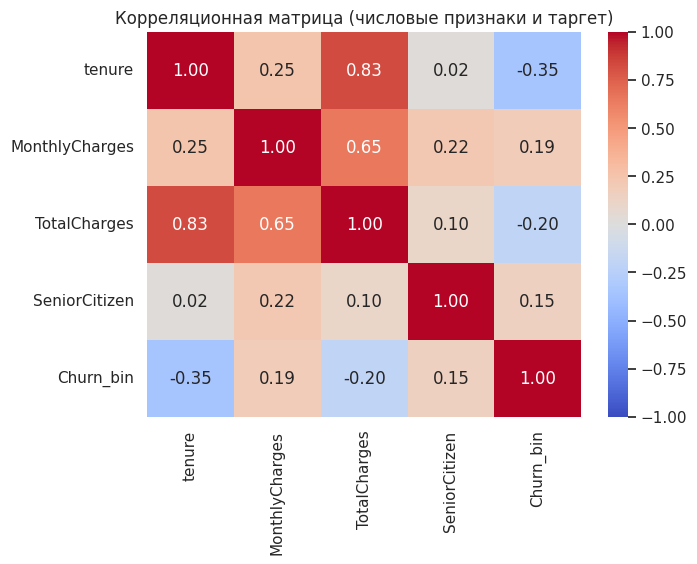

In [ ]:
corr = df[num_cols + ["SeniorCitizen", "Churn_bin"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляционная матрица (числовые признаки и таргет)")
plt.show()

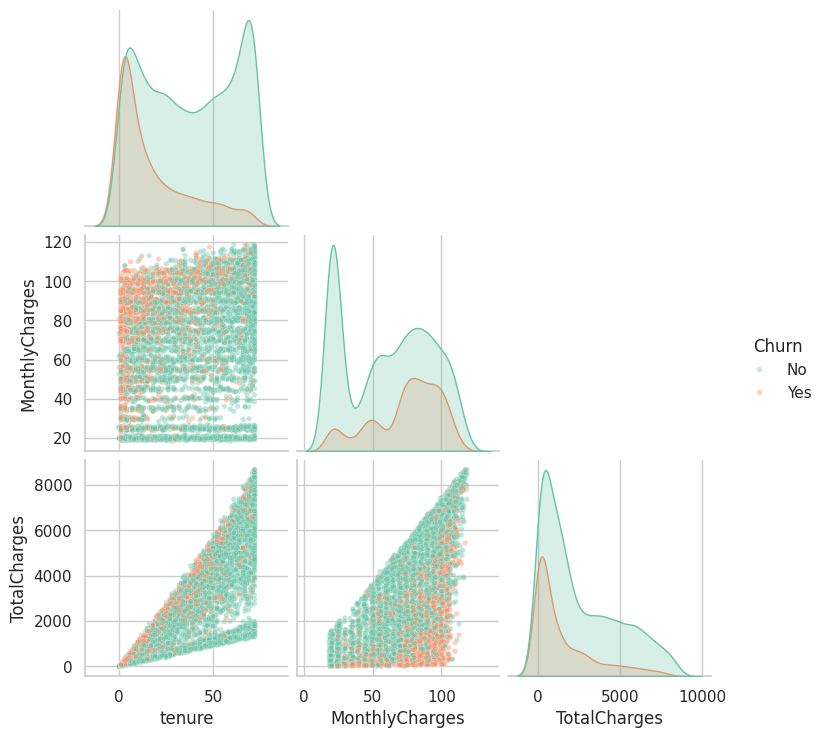

In [ ]:
sns.pairplot(df[num_cols + ["Churn"]], hue="Churn", corner=True,
             plot_kws={"alpha": 0.4, "s": 15})
plt.show()

**Комментарий.**
- `tenure` и `TotalCharges` сильно коррелируют (~0.83), что вполне ожидаемо: `TotalCharges ≈ tenure × MonthlyCharges`.
Для линейных моделей это **мультиколлинеарность**, нужно либо убрать один из признаков, либо использовать регуляризацию. Для деревьев и бустинга это не проблема.
- С целевой переменной наиболее связан `tenure` (отрицательная корреляция около −0.35): чем дольше клиент, тем реже он уходит.
`MonthlyCharges` связан с оттоком слабо положительно (около +0.19).
- Парные диаграммы подтверждают, что классы **не разделяются линейно** по числовым признакам, поэтому нужны категориальные признаки и нелинейные модели.

### 3.7 Взаимодействие признаков

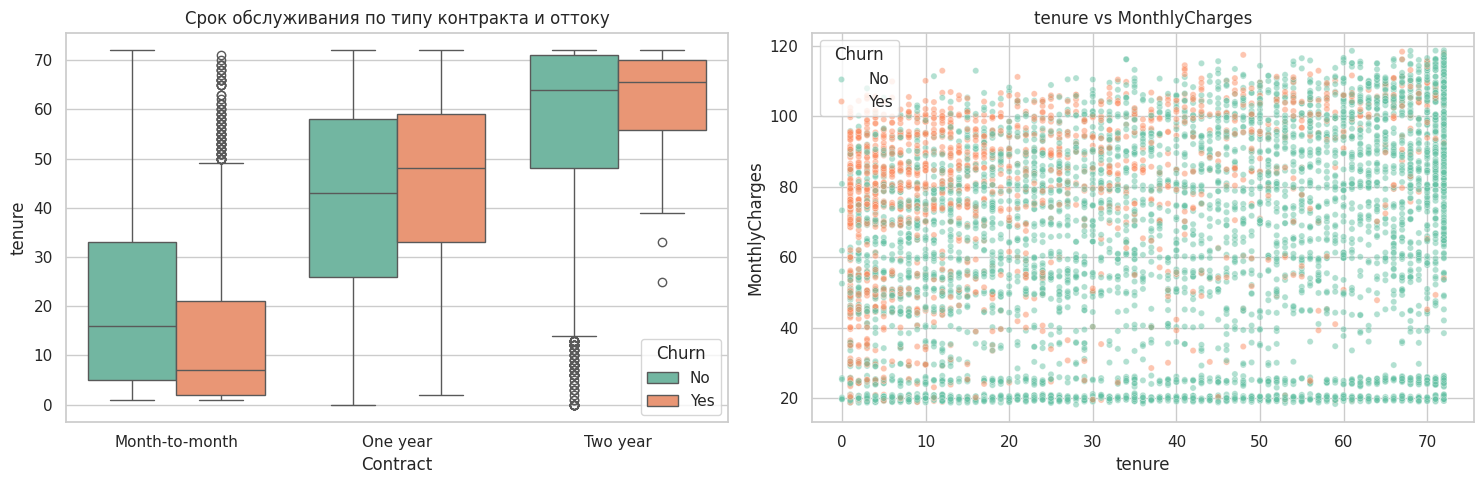

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x="Contract", y="tenure", hue="Churn", ax=axes[0])
axes[0].set_title("Срок обслуживания по типу контракта и оттоку")

sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn",
                alpha=0.5, s=20, ax=axes[1])
axes[1].set_title("tenure vs MonthlyCharges")
plt.tight_layout()
plt.show()

Наиболее рискованный сегмент — **новые клиенты с высоким ежемесячным платежом и помесячным контрактом**.
Это значит, что полезно создать производные признаки (например, `MonthlyCharges / tenure`, число подключённых доп. услуг, флаг «помесячный контракт + оптоволокно»),
а модели на деревьях смогут уловить такие взаимодействия автоматически.

## 4. Общие выводы и план предобработки

1. **Дисбаланс классов** (~73/27): стратифицированное разбиение, `class_weight`, оценка по PR-AUC/F1, подбор порога
2. **Пропуски:** `TotalCharges` — 11 значений у клиентов с `tenure = 0`; заполняем нулём
3. **Удаляемые признаки:** `customerID` (уникальный идентификатор, не несёт информации)
4. **Кодирование:** one-hot для категориальных признаков, объединение «No internet/phone service» с «No»
5. **Мультиколлинеарность:** `tenure` и `TotalCharges` сильно связаны — осторожно с линейными моделями, масштабирование числовых признаков
6. **Сильные предикторы:** `tenure`, `Contract`, `InternetService`, `PaymentMethod`, `TechSupport`, `MonthlyCharges`
7. **Feature engineering:** число доп. услуг, отношение платежа к сроку, флаги рискованных сегментов
8. **Модели для следующих шагов:** логистическая регрессия как baseline, затем случайный лес и градиентный бустинг